# 01a - Calibrations for PD-Centric Quarterly Panel

This notebook sets up calibrating parameters for the simulation. It finds the beta0, beta1, beta2 and rho_scale parameters that then feed into the simulation notebook.

## Part 1 - Imports, paths, and empirical target data

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import norm

pd.set_option("display.float_format", "{:.6f}".format)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks" and PROJECT_ROOT.parent.name == "simulation":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]

PROCESSED_DATA_DIR = PROJECT_ROOT / "simulation" / "data"
HIST_CHARGE_OFF_PATH = PROCESSED_DATA_DIR / "fred_loan_return_aligned.csv"
print(f"Project root: {PROJECT_ROOT}")
print(f"Historical charge-off file: {HIST_CHARGE_OFF_PATH}")


Project root: /Users/hannahokeeffe/Documents/Imperial/DFL_New
Historical charge-off file: /Users/hannahokeeffe/Documents/Imperial/DFL_New/simulation/data/fred_loan_return_aligned.csv


## Simulation calibration

Change this cell to recalibrate the panel. The key quarterly PD calibration controls are `beta0`, `beta1`, `pd_min`, and `pd_max`; the key allocation controls are `ell` and `lambda_shortfall`.

`AUTO_CALIBRATE_PD = True` searches over `beta0` and `beta1` to match the historical quarterly PD proxy mean and p95. Set it to `False` to use the hand-set beta values.

In [10]:
# Shared calibration settings
T = 1000
SEED = 42
LGD = 0.45
PD_CLIP_LOW = 1e-6
PD_CLIP_HIGH = 0.99

# Quarterly PD mapping range; beta0, beta1, beta2 are fitted below.
pd_min = 0.001
pd_max = 0.014

print("Calibration settings loaded.")


Calibration settings loaded.


## Part 2 - Historical quarterly calibration targets

In [11]:
hist = pd.read_csv(HIST_CHARGE_OFF_PATH)
hist_c_annualised_raw = hist["charge_off_rate"].dropna().astype(float)
charge_off_scale = 100.0 if hist_c_annualised_raw.max() > 1 else 1.0
hist_c_annualised = hist_c_annualised_raw / charge_off_scale
hist_c_quarterly = hist_c_annualised / 4
hist_pd_quarterly = (hist_c_quarterly / LGD).clip(PD_CLIP_LOW, PD_CLIP_HIGH)

print(f"Historical charge-off scale divisor: {charge_off_scale:g}")
print("Historical quarterly charge-off target, decimal units:")
display(hist_c_quarterly.describe(percentiles=[.50,.75,.90,.95,.99]).to_frame("hist_c_quarterly"))
print("Historical quarterly implied-PD target, decimal units:")
display(hist_pd_quarterly.describe(percentiles=[.50,.75,.90,.95,.99]).to_frame("hist_pd_quarterly"))


Historical charge-off scale divisor: 100
Historical quarterly charge-off target, decimal units:


,hist_c_quarterly
count,165.000000
mean,0.001889
std,0.001433
min,0.000300
50%,0.001375
75%,0.003000
90%,0.003820
95%,0.004710
99%,0.005819
max,0.006425


Historical quarterly implied-PD target, decimal units:


,hist_pd_quarterly
count,165.000000
mean,0.004197
std,0.003185
min,0.000667
50%,0.003056
75%,0.006667
90%,0.008489
95%,0.010467
99%,0.012931
max,0.014278


## Part 3 - Basel annual-PD correlation helper

Only the annual-PD Basel correlation needed to construct `rho_irb` is retained.


In [12]:
def clip_pd(pd, low=PD_CLIP_LOW, high=PD_CLIP_HIGH):
    return np.clip(np.asarray(pd, dtype=float), low, high)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def basel_asset_correlation(pd_annual):
    """Basel annual-PD correlation used as rho_irb and scaled for Vasicek q losses."""
    pd_annual = clip_pd(pd_annual)
    exp_term = (1 - np.exp(-50 * pd_annual)) / (1 - np.exp(-50))
    return 0.12 * exp_term + 0.24 * (1 - exp_term)


## Part 4 - Fixed latent macro state


In [13]:
def simulate_latent_state(T=1000, phi=0.95, sigma=0.35, seed=42):
    """Generate the fixed latent state path used by all beta candidates."""
    rng = np.random.default_rng(seed)
    state = np.zeros(T)
    cycle = np.zeros(T)
    for t in range(1, T):
        state[t] = phi * state[t - 1] + rng.normal(0, sigma)
        cycle[t] = 0.75 * cycle[t - 1] + rng.normal(0, 0.45)
    state = (state - state.mean()) / state.std(ddof=0)
    cycle = (cycle - cycle.mean()) / cycle.std(ddof=0)
    return pd.DataFrame({"latent_state": state, "latent_cycle": cycle})

latent = simulate_latent_state(T=T, seed=SEED)
print(f"Fixed latent path generated: T={len(latent)}, seed={SEED}")


Fixed latent path generated: T=1000, seed=42


## Part 5 - Beta calibration and specification comparison


## PD calibration experiment

First optimise the true quarterly PD mapping under Specifications A, B, and C. Specification B is then selected explicitly, and its fitted beta values are fixed before the separate RHO_SCALE calibration.


In [14]:
from scipy.optimize import differential_evolution

PD_MOMENTS = ["mean", "std", "p50", "p75", "p90", "p95", "p99", "min", "max"]
PD_CALIBRATION_BOUNDS = [(-6.0, 0.0), (0.0, 4.0), (-2.0, 2.0)]
PD_CALIBRATION_SEED = 2718

def quarterly_pd_from_latent(latent_df, beta0, beta1, beta2, pd_min, pd_max):
    s = latent_df["latent_state"].to_numpy()
    q = latent_df["latent_cycle"].to_numpy()
    pd_index = beta0 + beta1 * s + beta2 * q
    return np.clip(pd_min + sigmoid(pd_index) * (pd_max - pd_min), PD_CLIP_LOW, PD_CLIP_HIGH)

def pd_moments(values):
    x = np.asarray(values, dtype=float)
    return pd.Series({
        "mean": np.mean(x), "std": np.std(x, ddof=1), "p50": np.quantile(x,.50),
        "p75": np.quantile(x,.75), "p90": np.quantile(x,.90), "p95": np.quantile(x,.95),
        "p99": np.quantile(x,.99), "min": np.min(x), "max": np.max(x)
    })

hist_pd_targets = pd_moments(hist_pd_quarterly)

def pd_beta_objective(params, target_moments, objective_moments):
    simulated = pd_moments(quarterly_pd_from_latent(latent, *params, pd_min, pd_max))
    return float(sum(((simulated[m] - target_moments[m]) / max(abs(target_moments[m]), 1e-12)) ** 2 for m in objective_moments))

PD_SPECIFICATIONS = {
    "A_mean_p95": ["mean", "p95"],
    "B_mean_std_p90_p95": ["mean", "std", "p90", "p95"],
    "C_mean_std_p75_p90_p95_p99": ["mean", "std", "p75", "p90", "p95", "p99"],
}

def fit_beta_specification(name, objective_moments):
    result = differential_evolution(
        lambda params: pd_beta_objective(params, hist_pd_targets, objective_moments),
        bounds=PD_CALIBRATION_BOUNDS, seed=PD_CALIBRATION_SEED, polish=True,
        tol=1e-8, maxiter=120, popsize=10, workers=1
    )
    path = quarterly_pd_from_latent(latent, *result.x, pd_min, pd_max)
    simulated = pd_moments(path)
    table = pd.DataFrame({"historical":hist_pd_targets, "simulated":simulated})
    table["absolute_error"] = table["simulated"] - table["historical"]
    table["percentage_error"] = 100 * table["absolute_error"] / table["historical"].abs().clip(lower=1e-12)
    return {"name":name, "objective_moments":objective_moments, "params":result.x,
            "objective":float(result.fun), "path":path, "table":table}

pd_specification_results = {name: fit_beta_specification(name, moments) for name, moments in PD_SPECIFICATIONS.items()}
print("Historical quarterly implied-PD targets:")
display(hist_pd_targets.to_frame("historical_PD_quarterly"))
print("Beta calibration specifications:")
for name, fit in pd_specification_results.items():
    b0,b1,b2 = fit["params"]
    print(f"{name}: beta0={b0:.6f}, beta1={b1:.6f}, beta2={b2:.6f}, objective={fit['objective']:.8g}")
    display(fit["table"])

# Explicit selection: Specification B is the baseline passed to rho calibration.
SELECTED_PD_SPECIFICATION = "B_mean_std_p90_p95"
selected_beta_fit = pd_specification_results[SELECTED_PD_SPECIFICATION]
beta0_fixed, beta1_fixed, beta2_fixed = map(float, selected_beta_fit["params"])
PD_quarterly_true_fixed = selected_beta_fit["path"]
PD_annual_true_fixed = 1 - (1 - PD_quarterly_true_fixed) ** 4

print(f"\nSelected {SELECTED_PD_SPECIFICATION} and fixed beta values for rho calibration:")
print(f"beta0_fixed={beta0_fixed:.6f}, beta1_fixed={beta1_fixed:.6f}, beta2_fixed={beta2_fixed:.6f}")


Historical quarterly implied-PD targets:


,historical_PD_quarterly
mean,0.004197
std,0.003185
p50,0.003056
p75,0.006667
p90,0.008489
p95,0.010467
p99,0.012931
min,0.000667
max,0.014278


Beta calibration specifications:
A_mean_p95: beta0=-1.665825, beta1=1.487097, beta2=0.736158, objective=5.5562406e-18


,historical,simulated,absolute_error,percentage_error
mean,0.004197,0.004197,-0.000000,-0.000000
std,0.003185,0.003057,-0.000128,-4.024655
p50,0.003056,0.003130,0.000074,2.427080
p75,0.006667,0.005733,-0.000934,-14.009800
p90,0.008489,0.009268,0.000779,9.180393
p95,0.010467,0.010467,0.000000,0.000000
p99,0.012931,0.012409,-0.000522,-4.038531
min,0.000667,0.001009,0.000342,51.349106
max,0.014278,0.013684,-0.000594,-4.157556


B_mean_std_p90_p95: beta0=-1.764472, beta1=1.782915, beta2=0.038343, objective=0.0030231047


,historical,simulated,absolute_error,percentage_error
mean,0.004197,0.004135,-0.000062,-1.486443
std,0.003185,0.003063,-0.000122,-3.835458
p50,0.003056,0.003014,-0.000042,-1.360913
p75,0.006667,0.006036,-0.000631,-9.465412
p90,0.008489,0.008773,0.000284,3.346064
p95,0.010467,0.010619,0.000152,1.454184
p99,0.012931,0.012693,-0.000238,-1.840028
min,0.000667,0.001011,0.000345,51.698989
max,0.014278,0.013803,-0.000475,-3.326394


C_mean_std_p75_p90_p95_p99: beta0=-1.667464, beta1=1.729800, beta2=0.193870, objective=0.0070319622


,historical,simulated,absolute_error,percentage_error
mean,0.004197,0.004264,0.000067,1.597561
std,0.003185,0.003100,-0.000086,-2.686331
p50,0.003056,0.003163,0.000108,3.525168
p75,0.006667,0.006374,-0.000293,-4.387982
p90,0.008489,0.009001,0.000513,6.038130
p95,0.010467,0.010520,0.000053,0.506911
p99,0.012931,0.012654,-0.000277,-2.140255
min,0.000667,0.001014,0.000347,52.028225
max,0.014278,0.013805,-0.000473,-3.312253



Selected B_mean_std_p90_p95 and fixed beta values for rho calibration:
beta0_fixed=-1.764472, beta1_fixed=1.782915, beta2_fixed=0.038343


## RHO_SCALE calibration experiment

`rho_irb` is the Basel annual-PD correlation and remains unchanged for Basel IRB capital. `rho_vasicek_q` is the separately scaled quarterly correlation used only for the Vasicek realised-loss calibration.


In [15]:
# RHO_SCALE calibration experiment
RHO_SCALE_GRID = np.linspace(0.01, 1.0, 100)
RHO_SHOCK_SEEDS = np.arange(200)
RHO_CLIP_LOW = 1e-6
RHO_CLIP_HIGH = 1 - 1e-6

rho_irb = basel_asset_correlation(PD_annual_true_fixed)

def rho_vasicek_q_from_scale(rho_scale):
    return np.clip(rho_scale * rho_irb, RHO_CLIP_LOW, RHO_CLIP_HIGH)

def sample_vasicek_quarterly_chargeoffs(pd_quarterly_true, pd_annual_true, rho_scale, seed):
    # rho_irb is based on annual PD but is not modified for Basel capital.
    # rho_vasicek_q is used only for this quarterly loss draw.
    rho_irb_local = basel_asset_correlation(pd_annual_true)
    rho_vasicek_q = np.clip(rho_scale * rho_irb_local, RHO_CLIP_LOW, RHO_CLIP_HIGH)
    rng = np.random.default_rng(seed)
    z = rng.normal(0.0, 1.0, size=len(pd_quarterly_true))
    threshold = norm.ppf(clip_pd(pd_quarterly_true))
    default_rate_q = norm.cdf((threshold - np.sqrt(rho_vasicek_q) * z) / np.sqrt(1 - rho_vasicek_q))
    return np.clip(LGD * default_rate_q, 0.0, LGD)

def chargeoff_moments(values):
    x=np.asarray(values, dtype=float)
    return pd.Series({
        "mean": np.mean(x), "std": np.std(x, ddof=1), "p50": np.quantile(x,.50),
        "p75": np.quantile(x,.75), "p90": np.quantile(x,.90), "p95": np.quantile(x,.95),
        "p99": np.quantile(x,.99), "min": np.min(x), "max": np.max(x)
    })

hist_chargeoff_moments = chargeoff_moments(hist_c_quarterly)

def evaluate_rho_scale(rho_scale):
    seed_moments=[]
    for shock_seed in RHO_SHOCK_SEEDS:
        realised_c_q = sample_vasicek_quarterly_chargeoffs(
            PD_quarterly_true_fixed, PD_annual_true_fixed, rho_scale, int(shock_seed)
        )
        seed_moments.append(chargeoff_moments(realised_c_q))
    averaged = pd.DataFrame(seed_moments).mean()
    relative_error_std = (averaged["std"] - hist_chargeoff_moments["std"]) / hist_chargeoff_moments["std"]
    relative_error_p90 = (averaged["p90"] - hist_chargeoff_moments["p90"]) / hist_chargeoff_moments["p90"]
    relative_error_p95 = (averaged["p95"] - hist_chargeoff_moments["p95"]) / hist_chargeoff_moments["p95"]
    objective = relative_error_std**2 - relative_error_p90**2 - relative_error_p95**2
    return pd.Series({"RHO_SCALE":rho_scale, "objective":objective, **averaged.to_dict()})

rho_results = pd.DataFrame([evaluate_rho_scale(r) for r in RHO_SCALE_GRID])
selected_rho_scale = float(rho_results.loc[rho_results["objective"].idxmin(), "RHO_SCALE"])
print(f"Selected RHO_SCALE (minimum stated objective): {selected_rho_scale:.4f}")
display(rho_results[["RHO_SCALE","objective","mean","std","p90","p95","p99"]])


Selected RHO_SCALE (minimum stated objective): 0.0500


,RHO_SCALE,objective,mean,std,p90,p95,p99
0,0.010000,-0.001434,0.001860,0.001400,0.003987,0.004752,0.005842
1,0.020000,-0.002647,0.001860,0.001422,0.004011,0.004780,0.005999
2,0.030000,-0.003387,0.001860,0.001443,0.004024,0.004823,0.006152
3,0.040000,-0.003750,0.001860,0.001465,0.004036,0.004863,0.006299
4,0.050000,-0.004035,0.001860,0.001487,0.004052,0.004905,0.006436
...,...,...,...,...,...,...,...
95,0.960000,1.296924,0.001854,0.003344,0.004885,0.007693,0.016040
96,0.970000,1.330110,0.001854,0.003365,0.004887,0.007714,0.016141
97,0.980000,1.363859,0.001854,0.003385,0.004890,0.007734,0.016240
98,0.990000,1.398139,0.001854,0.003406,0.004893,0.007753,0.016341


## RHO_SCALE diagnostics and selected fit


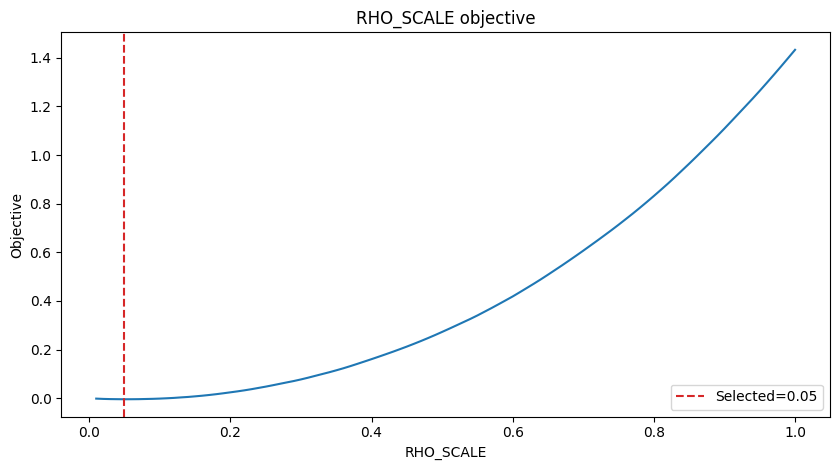

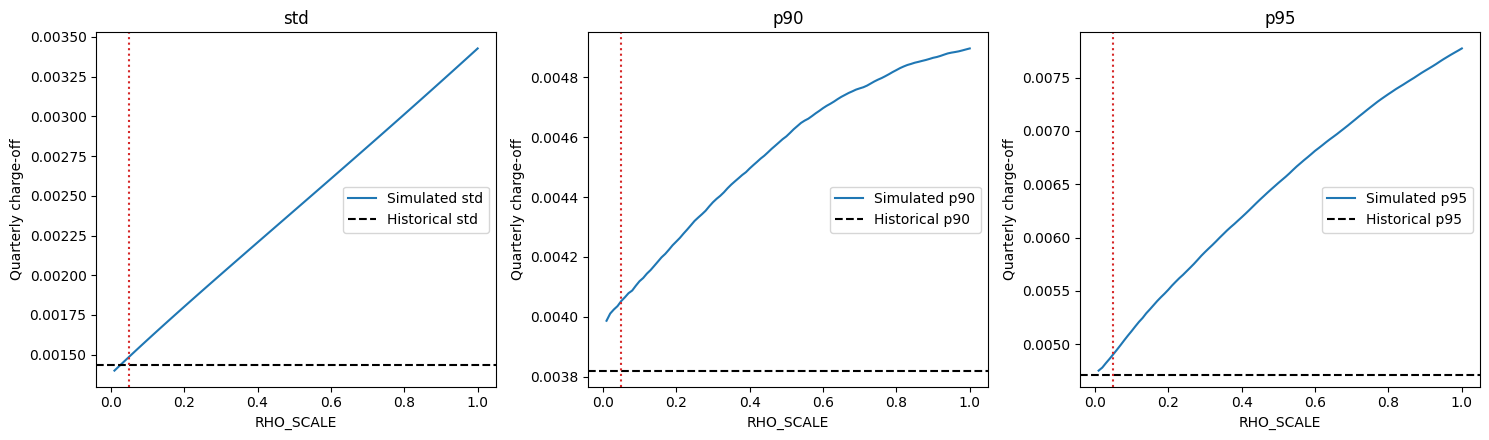

Selected RHO_SCALE: 0.0500
Selected rho_irb range: 0.128033 to 0.218055
Selected rho_vasicek_q range: 0.006402 to 0.010903


,historical,simulated_selected_rho,absolute_error,percentage_error
mean,0.001889,0.001860,-0.000029,-1.539361
std,0.001433,0.001487,0.000053,3.721285
p50,0.001375,0.001332,-0.000043,-3.128201
p75,0.003000,0.002650,-0.000350,-11.673824
p90,0.003820,0.004052,0.000232,6.082064
p95,0.004710,0.004905,0.000195,4.147934
p99,0.005819,0.006436,0.000617,10.600552
min,0.000300,0.000181,-0.000119,-39.748223
max,0.006425,0.008636,0.002211,34.409967


In [16]:
# RHO_SCALE diagnostics and selected fit
fig, ax = plt.subplots(figsize=(8.5,4.8))
ax.plot(rho_results["RHO_SCALE"], rho_results["objective"], lw=1.5)
ax.axvline(selected_rho_scale, color="tab:red", ls="--", label=f"Selected={selected_rho_scale:.2f}")
ax.set(xlabel="RHO_SCALE", ylabel="Objective", title="RHO_SCALE objective")
ax.legend(); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1,3,figsize=(15,4.5))
for ax, moment in zip(axes,["std","p90","p95"]):
    ax.plot(rho_results["RHO_SCALE"], rho_results[moment], label=f"Simulated {moment}")
    ax.axhline(hist_chargeoff_moments[moment], color="black", ls="--", label=f"Historical {moment}")
    ax.axvline(selected_rho_scale, color="tab:red", ls=":")
    ax.set(xlabel="RHO_SCALE", ylabel="Quarterly charge-off", title=moment)
    ax.legend()
plt.tight_layout(); plt.show()

selected_row = rho_results.loc[rho_results["RHO_SCALE"].eq(selected_rho_scale)].iloc[0]
selected_moments = selected_row[["mean","std","p50","p75","p90","p95","p99","min","max"]]
final_rho_table = pd.DataFrame({"historical":hist_chargeoff_moments, "simulated_selected_rho":selected_moments})
final_rho_table["absolute_error"] = final_rho_table["simulated_selected_rho"] - final_rho_table["historical"]
final_rho_table["percentage_error"] = 100 * final_rho_table["absolute_error"] / final_rho_table["historical"].abs().clip(lower=1e-12)
print(f"Selected RHO_SCALE: {selected_rho_scale:.4f}")
print(f"Selected rho_irb range: {rho_irb.min():.6f} to {rho_irb.max():.6f}")
print(f"Selected rho_vasicek_q range: {rho_vasicek_q_from_scale(selected_rho_scale).min():.6f} to {rho_vasicek_q_from_scale(selected_rho_scale).max():.6f}")
display(final_rho_table)


## Calibration hand-off

Use `beta0_fixed`, `beta1_fixed`, `beta2_fixed`, and `selected_rho_scale` as the hand-off values for the panel-generation notebook. `rho_irb = basel_asset_correlation(PD_annual_true)` must remain unchanged for Basel IRB capital; only `rho_vasicek_q = clip(RHO_SCALE * rho_irb, 1e-6, 1 - 1e-6)` is changed for quarterly Vasicek loss calculations.


## RHO_SCALE sensitivity: conventional objective

The primary objective above follows the requested signed formula. As a sensitivity check, this section uses a conventional all-positive loss: standard deviation, p90, and p95 relative-error squares are all added.

The interpretation is important: the historical charge-off series is an aggregate loan-book outcome, so diversification across loans can make it materially smoother than an individual-exposure or regulatory single-factor loss process. `RHO_SCALE` therefore calibrates the residual quarterly systematic shock to the observed aggregate series; it is not replacing `rho_irb` in Basel capital.


Signed-objective selection: RHO_SCALE=0.0500
Conventional-objective selection: RHO_SCALE=0.0100


,RHO_SCALE,objective,objective_standard,mean,std,p90,p95,p99,selection
0,0.010000,-0.001434,0.002530,0.001860,0.001400,0.003987,0.004752,0.005842,Conventional objective
4,0.050000,-0.004035,0.006804,0.001860,0.001487,0.004052,0.004905,0.006436,Signed objective


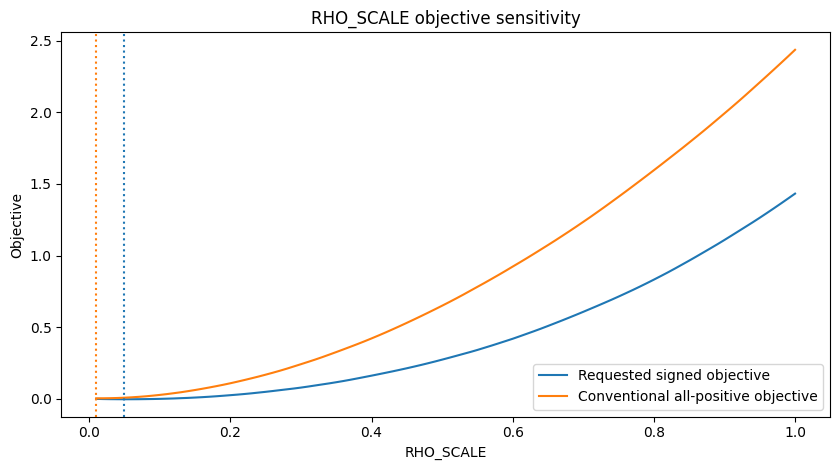

Conventional-objective selected moment table:


,historical,simulated_conventional_selected,absolute_error,percentage_error
mean,0.001889,0.001860,-0.000028,-1.507122
std,0.001433,0.001400,-0.000034,-2.341544
p50,0.001375,0.001348,-0.000027,-1.942224
p75,0.003000,0.002696,-0.000304,-10.146414
p90,0.003820,0.003987,0.000167,4.361223
p95,0.004710,0.004752,0.000042,0.894762
p99,0.005819,0.005842,0.000023,0.400531
min,0.000300,0.000322,0.000022,7.461414
max,0.006425,0.006948,0.000523,8.144016


In [17]:
# Conventional all-positive RHO_SCALE sensitivity
def rho_standard_objective(row):
    e_std = (row["std"] - hist_chargeoff_moments["std"]) / hist_chargeoff_moments["std"]
    e_p90 = (row["p90"] - hist_chargeoff_moments["p90"]) / hist_chargeoff_moments["p90"]
    e_p95 = (row["p95"] - hist_chargeoff_moments["p95"]) / hist_chargeoff_moments["p95"]
    return e_std**2 + e_p90**2 + e_p95**2

rho_results["objective_standard"] = rho_results.apply(rho_standard_objective, axis=1)
selected_rho_scale_standard = float(rho_results.loc[rho_results["objective_standard"].idxmin(), "RHO_SCALE"])

comparison = rho_results.loc[
    rho_results["RHO_SCALE"].isin([selected_rho_scale, selected_rho_scale_standard]),
    ["RHO_SCALE", "objective", "objective_standard", "mean", "std", "p90", "p95", "p99"]
].copy()
comparison["selection"] = np.where(
    comparison["RHO_SCALE"].eq(selected_rho_scale), "Signed objective", "Conventional objective"
)
print(f"Signed-objective selection: RHO_SCALE={selected_rho_scale:.4f}")
print(f"Conventional-objective selection: RHO_SCALE={selected_rho_scale_standard:.4f}")
display(comparison.sort_values("selection"))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(rho_results["RHO_SCALE"], rho_results["objective"], label="Requested signed objective")
ax.plot(rho_results["RHO_SCALE"], rho_results["objective_standard"], label="Conventional all-positive objective")
ax.axvline(selected_rho_scale, color="tab:blue", ls=":")
ax.axvline(selected_rho_scale_standard, color="tab:orange", ls=":")
ax.set(xlabel="RHO_SCALE", ylabel="Objective", title="RHO_SCALE objective sensitivity")
ax.legend()
plt.tight_layout(); plt.show()

standard_row = rho_results.loc[rho_results["RHO_SCALE"].eq(selected_rho_scale_standard)].iloc[0]
standard_moments = standard_row[["mean","std","p50","p75","p90","p95","p99","min","max"]]
standard_rho_table = pd.DataFrame({"historical":hist_chargeoff_moments, "simulated_conventional_selected":standard_moments})
standard_rho_table["absolute_error"] = standard_rho_table["simulated_conventional_selected"] - standard_rho_table["historical"]
standard_rho_table["percentage_error"] = 100 * standard_rho_table["absolute_error"] / standard_rho_table["historical"].abs().clip(lower=1e-12)
print("Conventional-objective selected moment table:")
display(standard_rho_table)
